# 03 Fourier Transform and Spectral Intuition

## Purpose

This notebook turns the ideas from sinusoids and complex exponentials into practical spectral intuition. The goal is not to start with the most abstract Fourier-transform derivation. It is to see what the discrete Fourier transform shows us in finite data, why spectral leakage appears, how windows change the picture, and how observation length controls what we can resolve.

## Prerequisites

- Notebook 01: Signals, Systems, and Sampling
- Notebook 02: Sinusoids, Complex Exponentials, and Phase
- Basic comfort with sine waves, frequency, and phase

## Learning Objectives

By the end of this notebook, you should be able to:

- explain what a spectrum represents in plain language,
- interpret the DFT or FFT as a numerical frequency-analysis tool,
- recognize spectral leakage as a finite-observation effect,
- describe how window choice changes sidelobes and peak width,
- explain why longer observation windows improve frequency resolution,
- and connect these tradeoffs to later detection, beamforming, and coherent processing notebooks.


## New Terms In This Notebook

- **Spectrum**: a description of how signal energy or magnitude is distributed across frequency.
- **Fourier transform**: the mathematical operation that represents a signal as a weighted combination of complex exponentials at different frequencies.
- **Discrete Fourier transform (DFT)**: the finite-sample version of that idea applied to a block of discrete data.
- **Fast Fourier transform (FFT)**: an efficient algorithm for computing the DFT.
- **Frequency bin**: one discrete frequency sample returned by the DFT.
- **Spectral leakage**: energy spreading across nearby frequency bins because the observed data window does not contain an integer number of cycles or is abruptly truncated.
- **Window function**: a weighting applied in time before the FFT to reduce abrupt edges and change leakage behavior.
- **Resolution**: how well two nearby frequencies can be distinguished in the spectrum.
- **Main lobe**: the broad central peak of a windowed spectral response.
- **Sidelobes**: smaller spectral ripples away from the main peak that can hide weak tones near strong ones.
- **Analysis block**: the finite chunk of samples we hand to one FFT. Changing its length changes both time localization and frequency resolution.


## Big Picture

Notebook 02 argued that complex exponentials are the natural language of oscillation. The Fourier transform uses that language as an analysis basis: it asks how much of each candidate frequency is present in the data.

In practice we never analyze an infinite signal. We analyze a finite chunk of samples. That finite observation is why real spectra show leakage, broadened peaks, and resolution limits. Those are not plotting artifacts. They are engineering constraints that matter later for pulse compression, Doppler estimation, beamforming, and SAS phase-history processing.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import apply_window, magnitude_spectrum, sine_wave, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal, plot_signals, plot_spectrum

set_plot_style()


def normalized_spectrum_db(signal: np.ndarray, sample_rate_hz: float, *, onesided: bool = True, floor_db: float = -80.0) -> tuple[np.ndarray, np.ndarray]:
    freqs, magnitude = magnitude_spectrum(signal, sample_rate_hz, onesided=onesided)
    magnitude = np.asarray(magnitude, dtype=float)
    magnitude = magnitude / np.max(magnitude)
    return freqs, 20.0 * np.log10(np.maximum(magnitude, 10.0 ** (floor_db / 20.0)))


def bin_spacing_hz(num_samples: int, sample_rate_hz: float) -> float:
    return sample_rate_hz / num_samples


## Assumptions

- We use short, synthetic tone mixtures so the frequency content is known in advance.
- We mostly analyze magnitude spectra and leave detailed phase interpretation for later notebooks where it matters directly.
- We treat the FFT as a frequency-analysis microscope, not as a black-box oracle.
- We focus on one-dimensional time signals before introducing range-Doppler maps or spatial spectra.


## From Time Waveform to Spectrum

A waveform in time tells us what the samples do moment by moment. A spectrum answers a different question: which oscillation rates are present, and how strongly?

The DFT does this by comparing the data block against many complex exponentials. If one basis frequency matches the data well, that bin receives a large response.


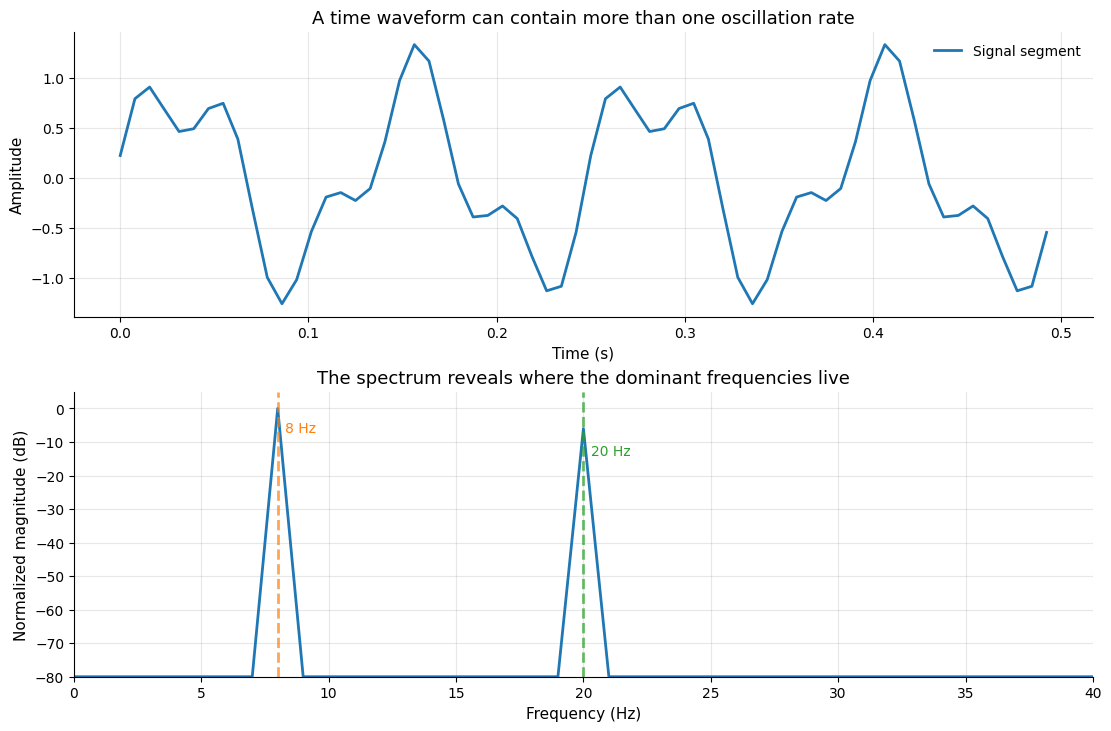

In [2]:
fs = 128.0
duration_s = 1.0
t = time_axis(int(fs * duration_s), fs)
x_mix = 0.9 * np.sin(2.0 * np.pi * 8.0 * t) + 0.45 * np.sin(2.0 * np.pi * 20.0 * t + np.deg2rad(30.0))
freqs_mix, spec_mix_db = normalized_spectrum_db(x_mix, fs)

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.0, 7.2))
plot_signal(t[:64], x_mix[:64], ax=axes[0], title="A time waveform can contain more than one oscillation rate", xlabel="Time (s)", ylabel="Amplitude", label="Signal segment")
axes[0].legend(loc="upper right")
plot_spectrum(freqs_mix, spec_mix_db, ax=axes[1], title="The spectrum reveals where the dominant frequencies live", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
axes[1].set_ylim(-80, 5)
axes[1].set_xlim(0, 40)
axes[1].axvline(8.0, color="C1", linestyle="--", alpha=0.7)
axes[1].axvline(20.0, color="C2", linestyle="--", alpha=0.7)
axes[1].text(8.3, -7, "8 Hz", color="C1")
axes[1].text(20.3, -14, "20 Hz", color="C2")
plt.show()


This first example is intentionally friendly: both tones land neatly on DFT bins because the observation is one second long and the frequencies are whole numbers of cycles per second. That is why the peaks look clean and concentrated.


## Finite Observation Creates Leakage

Real measurements rarely stop exactly at a cycle boundary. If the observed block cuts through a tone mid-cycle, the DFT no longer sees a perfectly bin-aligned oscillation. Instead, the mismatch spreads energy into neighboring bins.

The top plot below zooms in on the wrap from the end of the observed block back to the beginning. That is where the truncated tone shows a jump.

That spreading is spectral leakage.


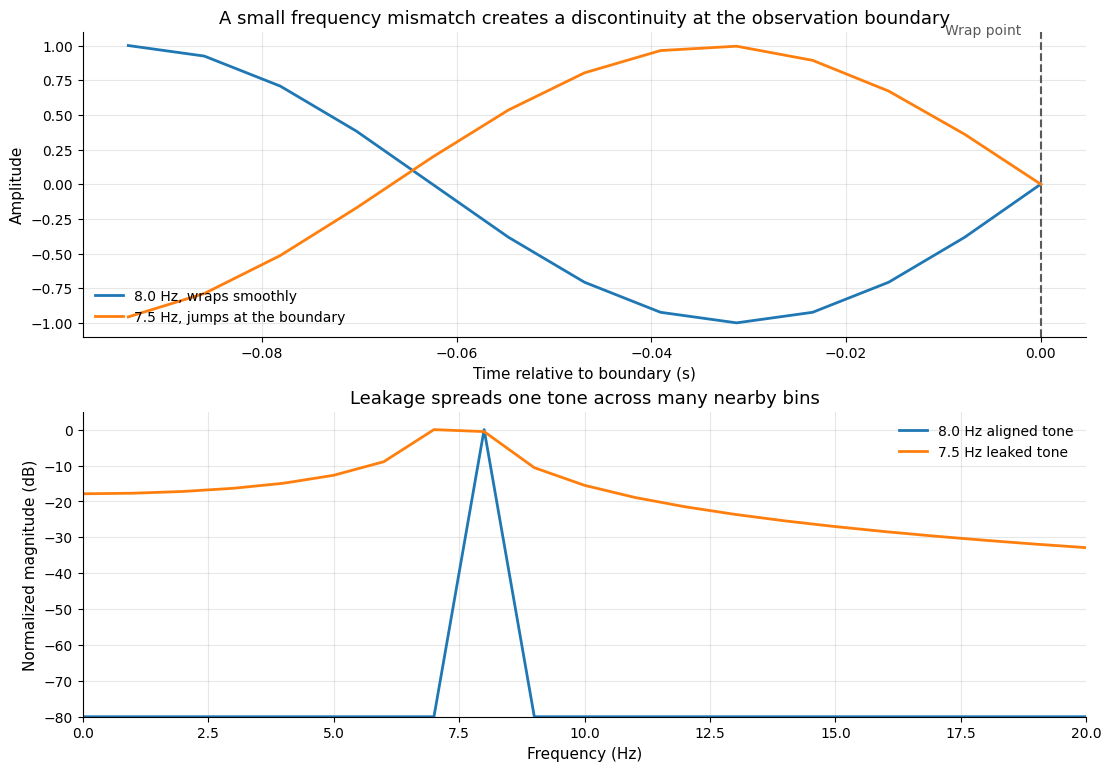

In [3]:
fs_leak = 128.0
duration_leak = 1.0
t_leak = time_axis(int(fs_leak * duration_leak), fs_leak)

x_bin_aligned = np.sin(2.0 * np.pi * 8.0 * t_leak)
x_leaky = np.sin(2.0 * np.pi * 7.5 * t_leak)

freqs_aligned, spec_aligned_db = normalized_spectrum_db(x_bin_aligned, fs_leak)
freqs_leaky, spec_leaky_db = normalized_spectrum_db(x_leaky, fs_leak)

wrap_times = np.concatenate([t_leak[-12:] - duration_leak, [0.0]])
wrap_aligned = np.concatenate([x_bin_aligned[-12:], [x_bin_aligned[0]]])
wrap_leaky = np.concatenate([x_leaky[-12:], [x_leaky[0]]])

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.0, 7.6))
plot_signals(wrap_times, [wrap_aligned, wrap_leaky], ax=axes[0], labels=["8.0 Hz, wraps smoothly", "7.5 Hz, jumps at the boundary"], title="A small frequency mismatch creates a discontinuity at the observation boundary", xlabel="Time relative to boundary (s)", ylabel="Amplitude")
axes[0].axvline(0.0, color="0.35", linestyle="--", linewidth=1.5)
axes[0].text(-0.002, 1.06, "Wrap point", ha="right", va="bottom", color="0.35")
axes[0].legend(loc="lower left")
plot_signals(freqs_aligned, [spec_aligned_db, spec_leaky_db], ax=axes[1], labels=["8.0 Hz aligned tone", "7.5 Hz leaked tone"], title="Leakage spreads one tone across many nearby bins", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(-80, 5)
axes[1].legend(loc="upper right")
plt.show()


The leaked tone has not become broadband in the physical world. The broad skirt is created by the finite observation itself. This matters because later we will often try to detect weak components near strong ones, and leakage from the strong component can obscure what we care about.


## Windowing Changes The Leakage Pattern

A rectangular window means we abruptly stop the data block at the beginning and end. That sharp edge is one reason leakage is strong.

A smoother window such as Hann or Hamming reduces sidelobes, but the main peak becomes broader. Windowing does not remove the tradeoff. It changes the shape of it.


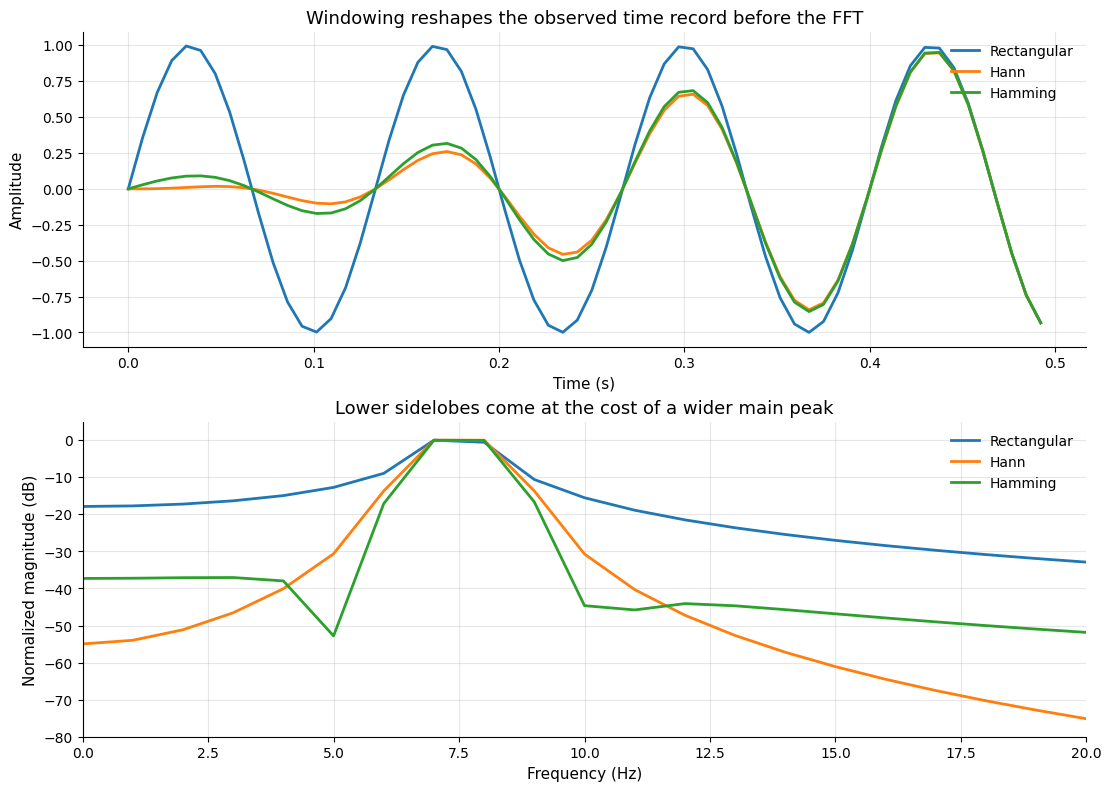

In [4]:
window_names = ["rectangular", "hann", "hamming"]
windowed_spectra = {}
for name in window_names:
    x_windowed = apply_window(x_leaky, name)
    freqs_win, spec_win_db = normalized_spectrum_db(x_windowed, fs_leak)
    windowed_spectra[name] = spec_win_db

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.0, 7.8))
plot_signals(t_leak[:64], [apply_window(x_leaky, name)[:64] for name in window_names], ax=axes[0], labels=["Rectangular", "Hann", "Hamming"], title="Windowing reshapes the observed time record before the FFT", xlabel="Time (s)", ylabel="Amplitude")
axes[0].legend(loc="upper right")
plot_signals(freqs_win, [windowed_spectra[name] for name in window_names], ax=axes[1], labels=["Rectangular", "Hann", "Hamming"], title="Lower sidelobes come at the cost of a wider main peak", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(-80, 5)
axes[1].legend(loc="upper right")
plt.show()


There is no universally best window. If you care most about suppressing far-out sidelobes, a tapered window can help. If you care most about narrow peak width, the rectangular window is sharper near the center but much leakier away from it.


## Longer Observation Improves Frequency Resolution

Frequency resolution depends on how long we observe the signal. Longer observation means finer DFT bin spacing and a better chance of separating nearby tones.

The example below uses tones at 10 Hz and 12 Hz. The tone spacing stays fixed at 2 Hz while the observation time changes.

The key scaling is

$$
\Delta f = \frac{f_s}{N} = \frac{1}{T_{obs}},
$$

where $f_s$ is sample rate, $N$ is number of samples, and $T_{obs}$ is observation time.


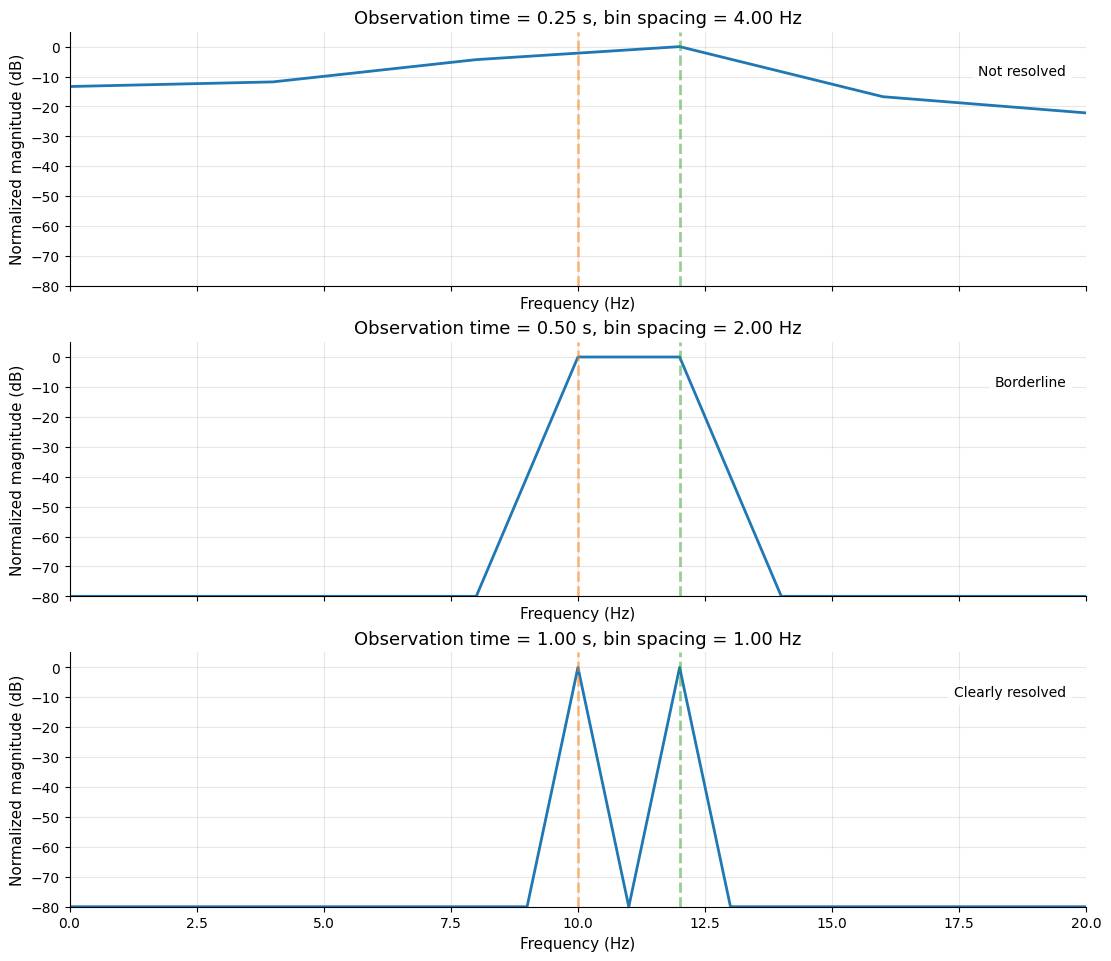

In [5]:
fs_res = 128.0
durations = [0.25, 0.5, 1.0]
f_a = 10.0
f_b = 12.0
resolution_labels = {
    0.25: "Not resolved",
    0.5: "Borderline",
    1.0: "Clearly resolved",
}

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.5), sharex=True)

for ax, duration_obs in zip(np.atleast_1d(axes), durations):
    t_res = time_axis(int(fs_res * duration_obs), fs_res)
    x_res = np.sin(2.0 * np.pi * f_a * t_res) + np.sin(2.0 * np.pi * f_b * t_res)
    freqs_res, spec_res_db = normalized_spectrum_db(x_res, fs_res)
    plot_spectrum(freqs_res, spec_res_db, ax=ax, title=f"Observation time = {duration_obs:.2f} s, bin spacing = {bin_spacing_hz(len(t_res), fs_res):.2f} Hz", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
    ax.set_xlim(0, 20)
    ax.set_ylim(-80, 5)
    ax.axvline(f_a, color="C1", linestyle="--", alpha=0.5)
    ax.axvline(f_b, color="C2", linestyle="--", alpha=0.5)
    ax.text(19.6, -6.0, resolution_labels[duration_obs], ha="right", va="top", fontsize=10, bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})

plt.show()


In [6]:
print(f"Tone separation: {f_b - f_a:.2f} Hz")
print("Bin spacing by observation length:")
for duration_obs in durations:
    n_obs = int(fs_res * duration_obs)
    print(f"  {duration_obs:>4.2f} s -> {bin_spacing_hz(n_obs, fs_res):.2f} Hz per bin")


Tone separation: 2.00 Hz
Bin spacing by observation length:
  0.25 s -> 4.00 Hz per bin
  0.50 s -> 2.00 Hz per bin
  1.00 s -> 1.00 Hz per bin


This is one of the most important practical Fourier-transform tradeoffs. If we want to resolve close frequencies, we need longer data records. But longer records can hide fast time variation and make us less responsive to changes.


## A Short Time-Frequency Tradeoff Example

Suppose a signal changes frequency halfway through the observation. A long FFT block gives a narrow spectrum, but it also mixes both halves of the record together. A shorter analysis block localizes time better, but with poorer frequency resolution.

In the example below, the short block is taken from the beginning of the record, so it mostly sees the 8 Hz portion and not the later 14 Hz portion.


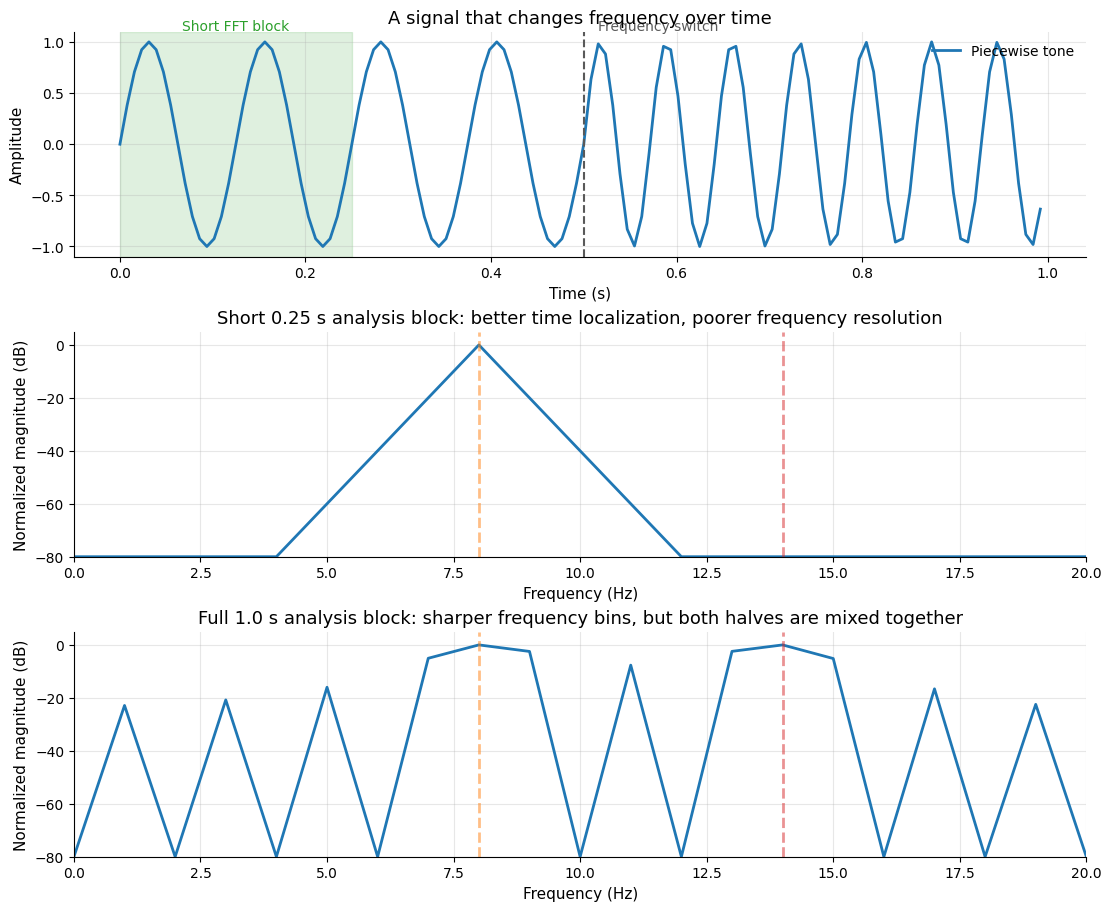

In [7]:
fs_tf = 128.0
duration_tf = 1.0
switch_time = 0.5
short_duration = 0.25
f_first = 8.0
f_second = 14.0
t_tf = time_axis(int(fs_tf * duration_tf), fs_tf)
x_tf = np.where(t_tf < switch_time, np.sin(2.0 * np.pi * f_first * t_tf), np.sin(2.0 * np.pi * f_second * t_tf))

short_block = x_tf[: int(short_duration * fs_tf)]
long_block = x_tf
freqs_short, spec_short_db = normalized_spectrum_db(short_block, fs_tf)
freqs_long, spec_long_db = normalized_spectrum_db(long_block, fs_tf)

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.0))
plot_signal(t_tf, x_tf, ax=axes[0], title="A signal that changes frequency over time", xlabel="Time (s)", ylabel="Amplitude", label="Piecewise tone")
axes[0].axvspan(0.0, short_duration, color="C2", alpha=0.15)
axes[0].axvline(switch_time, color="0.35", linestyle="--", linewidth=1.5)
axes[0].text(short_duration / 2.0, 1.08, "Short FFT block", ha="center", va="bottom", color="C2")
axes[0].text(switch_time + 0.015, 1.08, "Frequency switch", ha="left", va="bottom", color="0.35")
axes[0].legend(loc="upper right")
plot_spectrum(freqs_short, spec_short_db, ax=axes[1], title="Short 0.25 s analysis block: better time localization, poorer frequency resolution", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(-80, 5)
axes[1].axvline(f_first, color="C1", linestyle="--", alpha=0.5)
axes[1].axvline(f_second, color="C3", linestyle="--", alpha=0.5)
plot_spectrum(freqs_long, spec_long_db, ax=axes[2], title="Full 1.0 s analysis block: sharper frequency bins, but both halves are mixed together", xlabel="Frequency (Hz)", ylabel="Normalized magnitude (dB)")
axes[2].set_xlim(0, 20)
axes[2].set_ylim(-80, 5)
axes[2].axvline(f_first, color="C1", linestyle="--", alpha=0.5)
axes[2].axvline(f_second, color="C3", linestyle="--", alpha=0.5)
plt.show()


This is the bridge to later spectrogram and Doppler-style thinking. A single FFT block is not just a frequency tool. It also encodes a choice about how much time variation we are willing to blur together.


## Tradeoffs and Limitations

Several practical tradeoffs are visible in the figures above:

- Longer observations improve frequency resolution but smear together time variation.
- Shorter observations localize changes in time but make nearby frequencies harder to separate.
- Rectangular windows keep the narrowest main peak but create stronger sidelobes and leakage.
- Tapered windows suppress sidelobes but broaden the main lobe, which can hide close tones.
- FFT magnitude plots are useful, but they hide phase information that later notebooks will need for coherent processing.

This notebook also leaves out several important realities:

- additive noise,
- real sensor calibration errors,
- nonstationary signals more complicated than a simple tone switch,
- and two-dimensional transforms such as range-Doppler or spatial spectra.


## Recap

- The Fourier transform asks how much of each oscillation rate is present in the data.
- The FFT is the efficient numerical tool we use to compute that picture on finite sampled records.
- Finite observation creates leakage when a tone does not fit neatly into the analysis window.
- Windowing trades lower sidelobes for a wider main peak.
- Longer observation windows improve frequency resolution but weaken time localization.


## Suggested Next Questions

- How do filtering and convolution relate to spectra?
- Why does multiplication in frequency correspond to convolution in time?
- How do matched filters exploit Fourier-domain intuition in practical detection problems?

The next notebook answers those questions through convolution, filtering, and matched-filter intuition.
